In this notebook I want to calculate the harmonic intensity, using relevant saddle points as per ascending intersection

Next to do: I want to try to compare the spectrum for inlcuding the twzf trajectories with the ones where I include them. For that I need to calculate all (!) the saddle points first!

# Initialisation & Configuration

### Loading packages

In [1]:
using Plots
using DelimitedFiles
using Statistics
using Interpolations
using NLsolve
using DataInterpolations
using Sobol
using Peaks
# import ColorSchemes.jet
# import ColorSchemes.turbo

### Loading code

In [2]:
include("src/HeaderConstantsUnits.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderConstantsUnits.jl": No such file or directory

In [3]:
include("src/HeaderBeam2.jl");
include("src/HeaderBeamTC2.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderBeam2.jl": No such file or directory

In [4]:
include("src/HeaderHelperFunctions.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderHelperFunctions.jl": No such file or directory

In [5]:
include("src/HeaderTypes2.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderTypes2.jl": No such file or directory

In [6]:
include("src/HeaderEquations2.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderEquations2.jl": No such file or directory

In [7]:
include("src/SolveSPE2.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/SolveSPE2.jl": No such file or directory

In [8]:
#include("src/plotting/functions/plot-functions-XZ2.jl");

In [9]:
include("src/HeaderPlotting.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/HeaderPlotting.jl": No such file or directory

In [10]:
include("src/CalculateDipole2.jl");

LoadError: SystemError: opening file "/home/anne/OneDrive/HHGsimPL.jl/docs/src/CalculateDipole2.jl": No such file or directory

In [32]:
include("src/HeaderPlotting.jl");

### Setup

In [11]:
const Ip = IpAU(15.7596) #Argon
const lambda = 800
const qmin = 15
const qmax = 40
r = 1
s = 2
const epsilon = 0.0
qrange = qmin:qmax;
const Intensity1 = 1.5e14;

LoadError: UndefVarError: `IpAU` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Plotting the beam shape

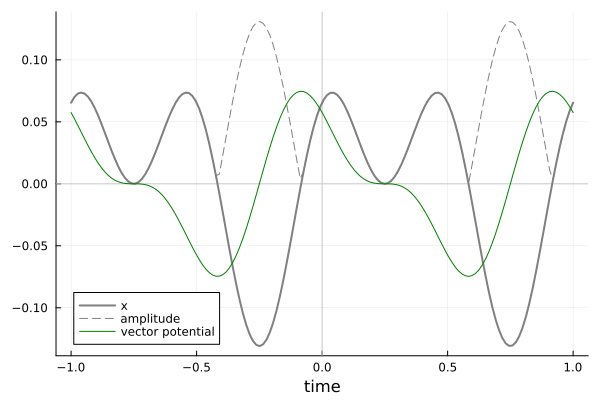

In [34]:
let
    beam = BeamBETC(Intensity1=Intensity1, 
    Intensity2=1*Intensity1,
    lambda=lambda,r=1,s=2,epsilon=0,
    phi=π/2)
    
    TC = TCycle(beam)
    Nt = 150
    times = range(-TC, stop = 1*TC, length = Nt)
    
    efield = [E(beam)(t) for t in times]
    
    plt = plot(times./TC, [e[1] for e in efield]
        , label = "x"
        , lw = 2
        , linestyle = :solid
        , linecolor = :grey)
    
    plot!(times./TC, [sqrt(sum(el.^2)) for el in efield]
        , label = "amplitude"
        , linestyle = :dash
        , linecolor = :grey)
    
    ### plotting the vector potential as well
    potential = [A(beam)(t) for t in times]./20

    plot!(times./TC, [pot[1] for pot in potential]
        , label = "vector potential"
        , linestyle = :solid
        , linecolor = :green)
    
    plot!(xlabel = "time")
    
    drawzerolines()
    
end

# Finding (all) saddle points

## ionisation window

### ionisation_windows()

In [12]:
function ionisation_windows(b::Beam)
    TC = TCycle(b)
    times = range(0, stop=1, length=150).*TC 
    efield = [E(b)(t) for t in times]
    amplitude = [sqrt(sum(el.^2)) for el in efield]
    
    # find maxima    
    pksmax, _ = findmaxima(amplitude)
    times_max = times[pksmax]

    # find minima    
    pksmin, _ = findminima(amplitude)
    times_min = [times[pksmin]..., TC .+ times[pksmin]...]
    
    windows = Vector{Tuple{Float64,Float64}}() 
    ### for each maximum, find the subsequent minimum
    for mx in times_max
        mn = times_min[findnext(t -> t > mx, times_min,1)]
#         println(typeof((mx,mn)))
        push!(windows,(mx,mn)./TC)
    end
    return windows   
end

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### tweak: find ionisation and recombination window

In [ ]:
using Interact

In [291]:
@manipulate throttle=.05 for phi = range(0,stop = 2*pi, step = 0.01 )
    
    beam = BeamBEOTC(Intensity1=Intensity1, 
    Intensity2=0.13*Intensity1,
    lambda=lambda,r=1,s=2,epsilon=epsilon,
    phi=phi)
    
    plot_efield_over_time(beam)

end

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["phi"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 629, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable{Any}(315), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/home/anne/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/home/anne/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/home/anne/.julia/packages/InteractBase/LJXv3/src/../assets/all.js"), Asset("css", nothing, "/home/anne/.julia/packages/InteractBase/LJXv3/src/../assets/style.css"), Asset("css", nothing, "/home/anne/.julia/packages/Interact/PENUy/src/../assets/bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition{ReentrantLock}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x00007fe986aceca0, Task (runnable) @0x00007fe986aceca0), ReentrantLock(nothing, Base.GenericCondition{Base.Threads.SpinLock}(Base.InvasiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), 0))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0.0\",\"0.01\",\"0.02\",\"0.03\",\"0.04\",\"0.05\",\"0.06\",\"0.07\",\"0.08\",\"0.09\",\"0.1\",\"0.11\",\"0.12\",\"0.13\",\"0.14\",\"0.15\",\"0.16\",\"0.17\",\"0.18\",\"0.19\",\"0.2\",\"0.21\",\"0.

Heuristic: use ionisation window1-TC for ti, and then for tr use window1.end to window1.start.

In [13]:
function ti_tr_windows(b::Beam)
    ti_win1 = ionisation_windows(b)[1]
    
    ti_win = ti_win1 .-1
    
    tr_win = (ti_win[2], ti_win1[1])
    return ti_win, tr_win
end 

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### testing it for my beam

In [70]:
let
    beam = BeamBETC(Intensity1=Intensity1, 
    Intensity2=1*Intensity1,
    lambda=lambda, r=1,s=2,epsilon=0,
    phi=π/2)
    
    b = beam 
    
    TC = TCycle(b)
    times = range(0, stop=1, length=200).*TC 
    efield = [E(b)(t) for t in times]
    amplitude = [sqrt(sum(el.^2)) for el in efield]
    
    # find maxima    
    pksmax, _ = findmaxima(amplitude)
    times_max = times[pksmax]

    # find minima    
    pksmin, _ = findminima(amplitude)
    times_min = [times[pksmin]..., TC .+ times[pksmin]...]
    
    println(-1 .+ times_min./TC)
    
    ti_tr_windows(beam)
    
    
end

[-0.7487437185929648, -0.4170854271356783, -0.085427135678392, 0.25125628140703515, 0.5829145728643217, 0.9145728643216082]


((-0.9597315436241611, -0.7516778523489933), (-0.7516778523489933, 0.040268456375838924))

## which saddles are relevant?

### is_saddle_relevant_ti/r() : function that determines if ascent route intersects original integration route

In [14]:
function is_saddle_relevant_ti(b::Beam, Ip::Real, saddle::Saddle,
    ti_cd::ComplexDomain = ComplexDomain(),
    tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min)-imag(ti_cd.max)*im,ti_cd.max + TCycle(b))
    )
    
    tr = saddle.tr 
    TC = TCycle(b)
    
    tir_values = range(real(ti_cd.min)-0.1*TC, stop=real(ti_cd.max)+0.1*TC, length=51) # I'm adding the ±0.1 because the contour line might reach out tout the domain otherwise
    tii_values = range(
        min(imag(ti_cd.min), 0.), 
        stop = imag(ti_cd.max), 
        length=51)    
    
    Sv_values = [S_v(b, Ip, ti, tr) for ti in (tir_values' .+ im*tii_values)]
  
    Sv_saddle = S_v(b, Ip, saddle)
    relevant = false
    
    mycurve = Curve2([
            (minimum(tir_values)./TC, 0.),
            (maximum(tir_values)./TC, 0.)])   # this is my original integration contour, agaiit's relevant I account for ausschweifende contour lines
    
    mycurve = Curve2([(minimum(tir_values)./TC, 0.), (maximum(tir_values)./TC, 0.)])    
  
    con_S_saddle_real = Contour.contour(tir_values./TC, tii_values./TC, real.(Sv_values'), real.(Sv_saddle))
    
#     println(imag(Sv_saddle))
    for curve in lines(con_S_saddle_real)
        ip = intersection(curve,mycurve)
        for ipx in ip
            ti_ip = (ipx.x + ipx.y*im)*TC
            Sv_ip = S_v(b, Ip, ti_ip, tr)
#             println(imag(Sv_ip))
            ascending = round(imag(Sv_ip - Sv_saddle),digits=5) >= 0
            crossing = crosses_point(curve,Point(reim(saddle.ti)./TC...),max(tii_values[2]-tii_values[1],1.5))
            if ascending && crossing
                relevant = true
#                 println("yes, there's a good ti one")
                return relevant
            end
        end
        
    end 
    return relevant
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [15]:
function is_saddle_relevant_tr(b::Beam, Ip::Real, saddle::Saddle,
    ti_cd::ComplexDomain = ComplexDomain(),
    tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min)-imag(ti_cd.max)*im,ti_cd.max + TCycle(b))
    )
    
    TC = TCycle(b)
    if abs(imag(saddle.tr)) <= 0.01*TC
#         println("here")
        return true
        
    elseif abs(imag(saddle.tr)) < 0.02*TC
#   println("here 2, because ", abs(imag(saddle.tr)) )
        str = saddle.tr
        # when the sp is eaxctly at the border I want to make sure it reaches up to line
        rg = max(abs(imag(str)),0.01*TC) * 2.0 
        trr_values = range(real(str) - rg, stop = real(str) + rg, length=51) # we want the length to be an odd number
        tri_values = range(imag(str) - rg, stop = imag(str) + rg, length=51)
    else
        N = 51
        trr_values = range(real(tr_cd.min), stop=real(tr_cd.max), length= N )
        tri_values = range(min(imag(tr_cd.min),0.),stop = imag(tr_cd.max),length= N)  
    end
    
    
    relevant = false

    ti = saddle.ti
    
    S_values = [S(b, Ip, ti, tr, saddle.q) for tr in (trr_values' .+ im*tri_values)]   
    S_saddle = (S(b, Ip, saddle))
#     con_S_saddle = Contour.contour(trr_values./TC, tri_values./TC, imag.(S_values'), -imag.(S_saddle))

    mycurve = Curve2([(real(tr_cd.min)./TC, 0.),(real(tr_cd.max)./TC, 0.)])

    con_S_saddle_real = Contour.contour(trr_values./TC, tri_values./TC, real.(S_values'), real.(S_saddle))
    for curve in lines(con_S_saddle_real)
#         println(curve)
            
        ip = intersection(curve,mycurve)
        for ipx in ip
            tr_ip = (ipx.x + ipx.y*im)*TC
            S_ip = S(b, Ip, ti, tr_ip, saddle.q)
            ascending = round(imag(S_ip - S_saddle),digits=5) >= 0
            crossing = crosses_point(curve,Point(reim(saddle.tr)./TC...), max(tri_values[2]-tri_values[1], 1.))
            if ascending && crossing
                relevant = true
#                 println("yes, there's a good tr one")
                return relevant
            end
        end        

    end

    return relevant

end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [97]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.10*Intensity1,
    phi = 2.47);

    q_values = collect(range(18, stop = 25, step = 1 ));
    
    saddlesTup_Dict = get_saddles_Dict(beam, Ip, q_values, ti_domain, tr_domain)
    
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    
    plot_sp_times_cp(beam, 
        vcat(values(saddlesTup_Dict)...), 
        filter(x -> 0 < real(x.qhc) < 45, thcs),
        ti_domain, tr_domain)  
end

## get saddles dict()

### get_saddles_Dict()

In [16]:
function get_saddles_Dict(b::Beam, Ip::Real, q_values::Vector{T}, 
    ti_cd::ComplexDomain,   
    tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min) - imag(ti_cd.max)*im,ti_cd.max + TCycle(b)); Nsobol::Int64 = 150, tt_minimal::Float64 = 0.005) where T <: Real
    
    saddles_Dict = Dict{T,Vector{Saddle}}()
    
    for q in q_values
        saddles_Dict[q] = find_saddles_sobol(q, b=b, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N = Nsobol, tt_minimal = tt_minimal)        
    end
    
    return saddles_Dict
    
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [362]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, 
        Intensity2=0.1*Intensity1,
        lambda=lambda,r=1,s=2,epsilon=epsilon,
        phi=2.0)
    
    ti_domain = ComplexDomain(-0.8,-0.5,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    dict = get_saddles_Dict(beam, Ip, collect(qrange), ti_domain,tr_domain)
    find_thcs_sobol(beam, Ip, ti_domain,tr_domain)
end

ComplexDomain(-88.27871134047638 - 38.621936211458404im, 55.17419458779773 + 38.621936211458404im)

### get_saddlesTup_Dict() (saddlesdict with relevant info)

In [17]:
function get_saddlesTup_Dict(b::Beam, Ip::Real, q_values::Vector{T}, 
    ti_cd::ComplexDomain,   
    tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min) - imag(ti_cd.max)*im,ti_cd.max + TCycle(b));
    Nsobol::Int64=150, tt_minimal::Float64 = 0.005) where T <: Real
    
    saddlesTup_Dict = Dict{Real,Vector{Tuple{Saddle,Bool}}}()
    
    for q in q_values
        saddles = find_saddles_sobol(q, b=b, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N= Nsobol, tt_minimal = tt_minimal)
        
        vec = Vector{Tuple{Saddle,Bool}}()
        for s in saddles 
            ti_relevant = is_saddle_relevant_ti(b, Ip, s, ti_cd, tr_cd)
            tr_relevant = is_saddle_relevant_tr(b, Ip, s, ti_cd, tr_cd)
            relevant = ti_relevant && tr_relevant
            push!(vec, (s,relevant))
        end
        saddlesTup_Dict[q] = vec
    end  
    
    return saddlesTup_Dict
    
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### parallelised

In [18]:
function get_saddlesTup_Dict_parallel(b::Beam, Ip::Real, q_values::Vector{T}, 
    ti_cd::ComplexDomain,   
    tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min) - imag(ti_cd.max)*im,ti_cd.max + TCycle(b)); Nsobol::Int64=150, tt_minimal::Float64 = 0.005) where T <: Real
    
    saddlesTup_Dict = Dict{Real,Vector{Tuple{Saddle,Bool}}}()
    
    Threads.@threads for q in q_values
        saddles = find_saddles_sobol(q, b=b, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N = Nsobol, tt_minimal = tt_minimal)
        
        vec = Vector{Tuple{Saddle,Bool}}()
        for s in saddles 
            ti_relevant = is_saddle_relevant_ti(b, Ip, s, ti_cd, tr_cd)
            tr_relevant = is_saddle_relevant_tr(b, Ip, s, ti_cd, tr_cd)
            relevant = ti_relevant && tr_relevant
            push!(vec, (s,relevant))
        end
        saddlesTup_Dict[q] = vec
    end  
    
    return saddlesTup_Dict
    
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## plotting saddle points in the complex plane

### plot_sp_times_cp()

In [19]:
function plot_sp_times_cp(b::Beam, saddles::Vector{Saddle}, thcs::Vector{Thc},
        ti_cd::ComplexDomain = ComplexDomain(),
        tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min)-imag(ti_cd.max)*im,ti_cd.max + TCycle(b)),
        tt_cd::ComplexDomain = ComplexDomain()) 
    
    plt_tt = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "travel time")
    plt_ti = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "ionization time")
    plt_tr = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "recombination time")
    
    for s in saddles
        col = harmonic_color(real(s.q), [real(s.q) for s in saddles])
        spmarker = (:o,2,col,stroke(2,col))
        
        ttr = real(s.tr-s.ti)./TCycle(b)
        tti = imag(s.tr-s.ti)./TCycle(b)
        
        ### travel time
        scatter!(plt_tt,(ttr,tti), aspectratio = 1., marker = spmarker)
        scatter!(plt_ti,reim(s.ti)./TCycle(b), aspectratio = 1., marker = spmarker)
        scatter!(plt_tr,reim(s.tr)./TCycle(b), aspectratio = 1., marker = spmarker)
    end

    plot_shape(plt, cd::ComplexDomain) =
        plot!(plt, Shape(real.([cd.min,cd.max,cd.max,cd.min])./TCycle(b),
            imag.([cd.min,cd.min,cd.max,cd.max])./TCycle(b)), 
        fillalpha = 0,
        fillcolor = :yellow, 
        linecolor = :grey,
        linewidth = 3 )
    
    plot_shape(plt_ti,ti_cd)
    
    if !iszero(ti_cd.min)
        plot_shape(plt_tr, tr_cd)
    end
    
    thcmarker = (:diamond,3,:black,stroke(3,:black))
    for thc in thcs
        ttr = real(thc.trhc-thc.tihc)./TCycle(b)
        tti = imag(thc.trhc-thc.tihc)./TCycle(b)

        scatter!(plt_tt,(ttr,tti), aspectratio = 1., marker = thcmarker)
        scatter!(plt_ti,reim(thc.tihc)./TCycle(b), aspectratio = 1., marker = thcmarker)
        scatter!(plt_tr,reim(thc.trhc)./TCycle(b), aspectratio = 1., marker = thcmarker)
    end 
    
    return plot(plt_ti, plt_tr, plt_tt, layout=(1,3), size = (900,250))
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### test: plot all saddle points in the complex plane

Thc[tihc: 24.426 + 19.499im, trhc: 78.094 - 1.3135im, qhc: 10.171 - 2.6016e-12im
, tihc: 25.775 + 19.271im, trhc: 61.397 - 0.87333im, qhc: 20.993 - 2.5164im
, tihc: 26.117 + 19.394im, trhc: 98.879 - 0.50795im, qhc: 37.027 + 1.6776im
, tihc: 27.805 + 19.607im, trhc: 136.83 - 0.14486im, qhc: 10.187 + 0.0042218im
]


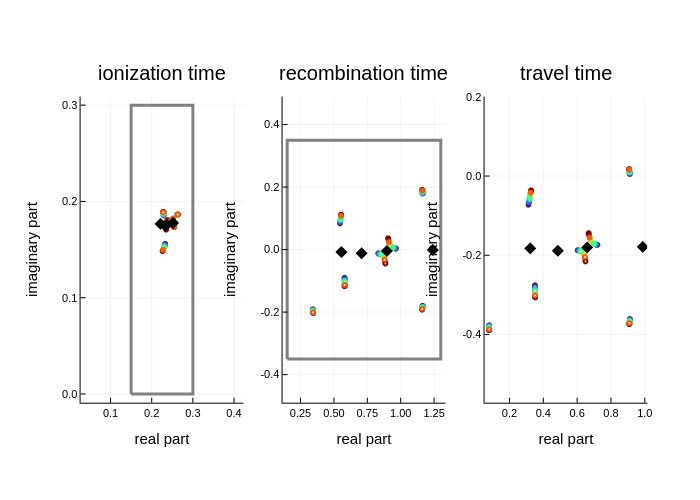

In [91]:
let 
    beam = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)
    
    q_values = collect(range(30, stop = 40, step=1))
    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
    tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam);
    saddles_Dict = get_saddlesTup_Dict_parallel(beam, Ip, q_values, ti_domain,tr_domain, Nsobol = 200)
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    filter!(x -> (0 < real(x.qhc) < 45) && (real(x.trhc-x.tihc) < TCycle(beam)), thcs)
    println(thcs)
    
    plot_sp_times_cp(beam, vcat(values(saddles_Dict)...),
#         vcat(values(saddles_Dict)...),
        thcs, ti_domain, tr_domain)    
    
end

In [61]:
plotlyjs()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

### plot_sp_times_cp()  with discard info

In [20]:
function plot_sp_times_cp(b::Beam, saddlesTup::Vector{Tuple{Saddle,Bool}}, thcs::Vector{Thc},
        ti_cd::ComplexDomain = ComplexDomain(),
        tr_cd::ComplexDomain = ComplexDomain(real(ti_cd.min)-imag(ti_cd.max)*im,ti_cd.max + TCycle(b)),
        tt_cd::ComplexDomain = ComplexDomain()) 
    
    plt_tt = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "travel time")
    plt_ti = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "ionization time")
    plt_tr = plot(legend = false, xlabel = "real part", ylabel = "imaginary part", title = "recombination time")
    
    for tup in saddlesTup
        s = tup[1]
        relevant = tup[2]
        
        col = harmonic_color(real(s.q), [real(tup[1].q) for tup in saddlesTup])
        spmarker = (:o,2, relevant ? col : :white,stroke(2,col))
        
        ttr = real(s.tr-s.ti)./TCycle(b)
        tti = imag(s.tr-s.ti)./TCycle(b)
        
        ### travel time
        scatter!(plt_tt,(ttr,tti), aspectratio = 1., marker = spmarker)
        scatter!(plt_ti,reim(s.ti)./TCycle(b), aspectratio = 1., marker = spmarker)
        scatter!(plt_tr,reim(s.tr)./TCycle(b), aspectratio = 1., marker = spmarker)
    end

    plot_shape(plt, cd::ComplexDomain) =
        plot!(plt, Shape(real.([cd.min,cd.max,cd.max,cd.min])./TCycle(b),
            imag.([cd.min,cd.min,cd.max,cd.max])./TCycle(b)), 
        fillalpha = 0,
        fillcolor = :yellow, 
        linecolor = :grey,
        linewidth = 3 )
    
    plot_shape(plt_ti,ti_cd)
    
    if !iszero(ti_cd.min)
        plot_shape(plt_tr, tr_cd)
    end
    
    thcmarker = (:diamond,3,:black,stroke(3,:black))
    for thc in thcs
        ttr = real(thc.trhc-thc.tihc)./TCycle(b)
        tti = imag(thc.trhc-thc.tihc)./TCycle(b)

        scatter!(plt_tt,(ttr,tti), aspectratio = 1., marker = thcmarker)
        scatter!(plt_ti,reim(thc.tihc)./TCycle(b), aspectratio = 1., marker = thcmarker)
        scatter!(plt_tr,reim(thc.trhc)./TCycle(b), aspectratio = 1., marker = thcmarker)
    end 
    
    return plot(plt_ti, plt_tr, plt_tt, layout=(1,3), size = (900,250))
end;

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## testing it for my configuration

In [29]:
saddlesdict = let
    beam = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)
    
    q_values = collect(range(15, stop = 40, step=1))
    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
    tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam);    
    get_saddlesTup_Dict_parallel(beam, Ip, q_values, ti_domain, tr_domain, tt_minimal = 0.01)
    
end

Dict{Real, Vector{Tuple{Saddle, Bool}}} with 26 entries:
  35 => [(ti: 25.23 + 20.7im, tr: 63.99 - 11.69im, q35.0, 0), (ti: 25.32 + 16.7…
  20 => [(ti: 24.8 + 19.43im, tr: 86.9 - 1.13im, q20.0, 1), (ti: 25.12 + 19.64i…
  16 => [(ti: 24.64 + 19.46im, tr: 84.74 - 1.13im, q16.0, 1), (ti: 24.76 + 19.5…
  24 => [(ti: 24.97 + 19.4im, tr: 88.85 - 1.17im, q24.0, 1), (ti: 25.32 + 20.04…
  28 => [(ti: 25.16 + 19.36im, tr: 90.8 - 1.26im, q28.0, 1), (ti: 25.31 + 20.35…
  30 => [(ti: 25.27 + 19.34im, tr: 91.84 - 1.34im, q30.0, 1), (ti: 25.29 + 20.4…
  17 => [(ti: 24.68 + 19.45im, tr: 85.32 - 1.13im, q17.0, 1), (ti: 24.84 + 19.5…
  37 => [(ti: 25.18 + 16.58im, tr: 60.93 + 11.62im, q37.0, 1), (ti: 25.2 + 20.7…
  23 => [(ti: 24.93 + 19.41im, tr: 88.37 - 1.16im, q23.0, 1), (ti: 25.31 + 19.9…
  19 => [(ti: 24.76 + 19.44im, tr: 86.39 - 1.13im, q19.0, 1), (ti: 25.02 + 19.5…
  22 => [(ti: 24.88 + 19.42im, tr: 87.89 - 1.15im, q22.0, 1), (ti: 25.27 + 19.8…
  32 => [(ti: 25.26 + 20.57im, tr: 63.97 - 10.75im, 

Thc[tihc: 24.426 + 19.499im, trhc: 78.094 - 1.3135im, qhc: 10.171 - 2.6016e-12im
, tihc: 25.775 + 19.271im, trhc: 61.397 - 0.87333im, qhc: 20.993 - 2.5164im
, tihc: 26.117 + 19.394im, trhc: 98.879 - 0.50795im, qhc: 37.027 + 1.6776im
, tihc: 27.805 + 19.607im, trhc: 136.83 - 0.14486im, qhc: 10.187 + 0.0042218im
]


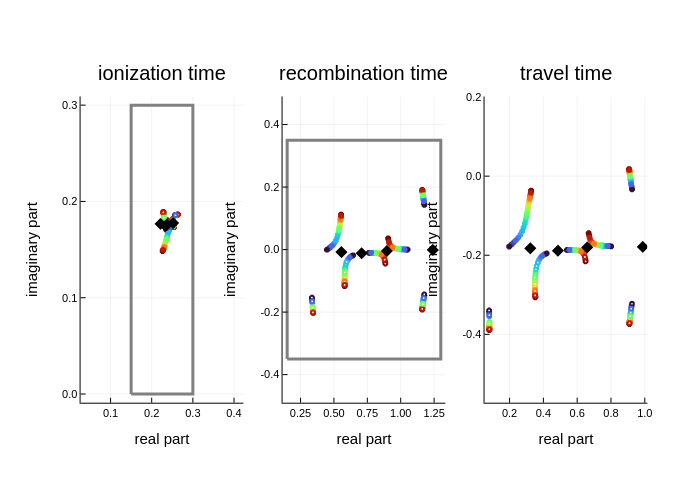

In [123]:
let 
    beam = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)
    
    q_values = collect(range(25, stop = 40, step=1))
    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
    tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam); 
#     saddles_Dict = get_saddlesTup_Dict_parallel(beam, Ip, q_values, ti_domain,tr_domain)
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    filter!(x -> (0 < real(x.qhc) < 45) && (real(x.trhc-x.tihc) < TCycle(beam)), thcs)
    println(thcs)
    
    plot_sp_times_cp(beam, vcat(values(saddlesdict)...),
#         vcat(values(saddles_Dict)...),
        thcs, ti_domain, tr_domain)    
    
end

## plotting saddle points in time, together with e field

### variant 1 (unfavourable)

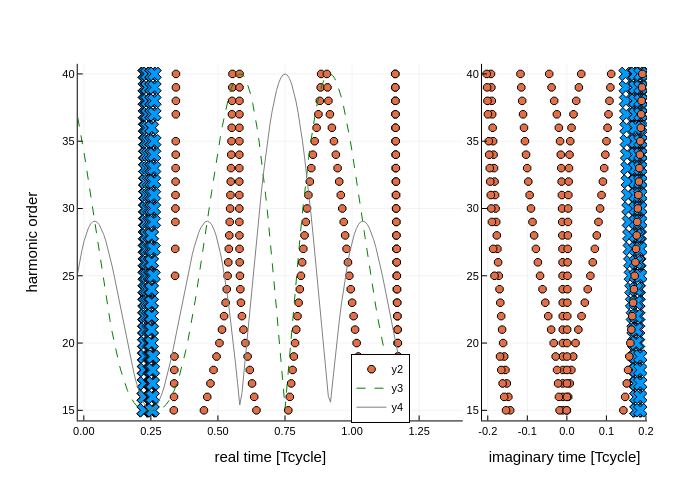

In [126]:
let
    beam = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)   
    
    saddles = [tup[1] for tup in vcat(values(saddlesdict)...)]
    TC = TCycle(beam)
    
    ### ionization time
	tir = [real(s.ti) for s in saddles]./TC
	tii = [imag(s.ti) for s in saddles]./TC

	### recombination time
	trr = [real(s.tr) for s in saddles]./TC
	tri = [imag(s.tr) for s in saddles]./TC
    
    orders = [real(s.q) for s in saddles]
    
    plt1 = scatter(tir,orders,markershape = :xcross, markersize=6, label = "",
        xlims = (maximum(trr)-1.2,maximum(trr)*1.2))
	scatter!(trr,orders, markershape = :o)
	scatter!(legend = false, xlabel = "real time [Tcycle]", ylabel = "harmonic order")


	#### plot vector potential (A) and electric field (E) as well
	times = range(min(maximum(trr)-1.2, minimum(trr)), stop=maximum(trr), length = 150)
    
	amplA = field_amplitude.( A(beam).(times.*TC) )
	amplA .= amplA ./maximum(amplA) .* (maximum(orders)-minimum(orders)) .+ minimum(orders)

	plot!(times,amplA, linestyle = :dash, linecolor = :green)

	amplE = field_amplitude.( E(beam).(times.*TC) ) #[p[1]^2 + p[2]^2 for p in fieldA]
	amplE .= amplE ./maximum(amplE) .* (maximum(orders)-minimum(orders)) .+ minimum(orders)

	plot!(times,amplE, linecolor = :grey, linestyle = :solid)
    
    plt2 = scatter(tii, orders, markershape = :xcross, markersize=6, label ="")
	scatter!(tri,orders, markershape = :o, label ="")
	scatter!(legend = :bottom, markeralpha = 0.6, xlabel = "imaginary time [Tcycle]")


	plt3 = plot(plt1, plt2, size = (800,400),layout = grid(1,2, widths = [0.7,0.3]))#@layout[a ; b])

    return plt3
end

### variant 2

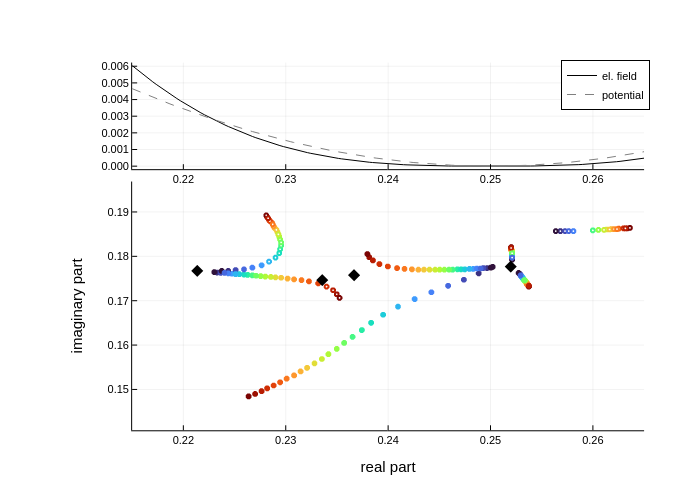

In [171]:
let
    saddlesTup = vcat(values(saddlesdict)...)
    beam = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1, s=2,epsilon=0,
        phi=π/2)
    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
     tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam); 
    TC = TCycle(beam)
    timin = 0.215#real(ti_domain.min)/TC
    timax = 0.265 #real(ti_domain.max)/TC    
    
    b = beam 
    
    plt_ti = plot(legend = false, xlabel = "real part", ylabel = "imaginary part")

    for tup in saddlesTup
        s = tup[1]
        relevant = tup[2]
        
        col = harmonic_color(real(s.q), [real(tup[1].q) for tup in saddlesTup])
        spmarker = (:o,2, relevant ? col : :white,stroke(2,col))
        
        ### travel time
        scatter!(plt_ti,reim(s.ti)./TCycle(b), aspectratio = 1., marker = spmarker, label = false)
    end
    
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    filter!(x -> (0 < real(x.qhc) < 45) && (real(x.trhc-x.tihc) < TCycle(beam)), thcs)    
  
    
    thcmarker = (:diamond,3,:black,stroke(3,:black))
    for thc in thcs
        scatter!(plt_ti,reim(thc.tihc)./TCycle(b), aspectratio = 1., marker = thcmarker, label = "")
    end 

    plot!(plt_ti, xlims=(timin,timax), legend = false)

    
	#### plot vector potential (A) and electric field (E) as well
	times = range(timin, stop=timax, length = 150)
    
	amplA = field_amplitude.( A(beam).(times.*TC) )
	amplA .= amplA #./maximum(amplA)

	plt_field = plot(times,amplA, linestyle = :solid, linecolor = :black, label = "el. field")

	amplE = field_amplitude.( E(beam).(times.*TC) ) #[p[1]^2 + p[2]^2 for p in fieldA]
	amplE .= amplE# ./maximum(amplE)

	plot!(plt_field, times,amplE, linecolor = :grey, linestyle = :dash, label = "potential")    
    plot!(plt_field, xlims=(timin,timax) )
    
    
    return plot(plt_field, plt_ti, layout = grid(2,1, heights = [0.3,0.7]), size = (400,600), legend = true)
end     

# Calculating the dipole

### dipole_from_saddles()

In [21]:
function dipole_from_saddles(b::Beam, Ip::Float64, Saddles::Vector{Tuple{Saddle,Bool}})
    summed_dip = [0 + 0. *im; 0 + 0. *im]

    for tup in Saddles
        if tup[2]
            dip = dipole(b, Ip, tup[1])
            summed_dip += dip
        end
    end 
    
  return summed_dip
end 

LoadError: UndefVarError: `Beam` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### initial test

In [194]:
let 
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0,
    phi=π/2)
    q = 20
    dipole_from_saddles(beam, Ip, saddlesdict[q])
end

2-element Vector{ComplexF64}:
 1.0426694532053579e-6 - 4.195289696066676e-6im
                   0.0 + 0.0im

# Plotting a spectrum

In [37]:
dipolesdict = let 
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)
    
    q_values = unique([tup[1].q for tup in vcat(values(saddlesdict)...)])
    dict = Dict{Real,Vector{ComplexF64}}()
    for q in q_values
      dict[q] = dipole_from_saddles(beam, Ip, saddlesdict[q])
    end
    dict
end;   

In [35]:
let 
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)
    E(beam)(50)
end

2-element Vector{Float64}:
 0.07343512770537969
 0.0

In [45]:
harmonic_intensity(beam05, dipoles_Dict05[20]..., 20)

7.544290714004797e-16

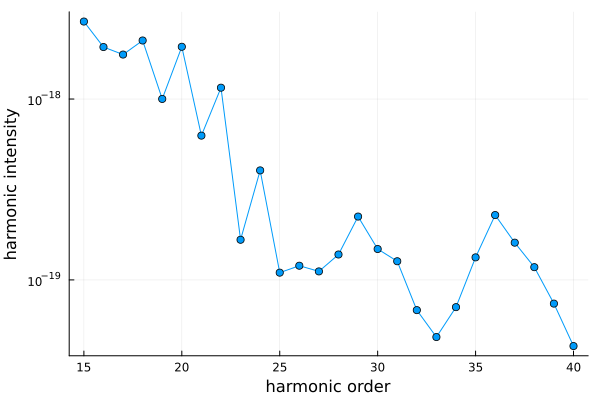

In [38]:
let
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)   
    q_values = sort(unique([tup[1].q for tup in vcat(values(saddlesdict)...)]))
    
    intensities = [harmonic_intensity(beam, dipolesdict[q]..., q) for q in q_values]
    
    plot(q_values, intensities, yaxis= :log, marker=true, 
        legend = false, xlabel = "harmonic order", ylabel = "harmonic intensity")
end

### trying without the trajectories that start where the field goes to zero

In [56]:
saddlesdict_wo = let 
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)
    
    q_values = unique([tup[1].q for tup in vcat(values(saddlesdict)...)])
    
    dict = Dict{Number, Vector{Tuple{Saddle, Bool}}}()
    for q in q_values
        saddles = saddlesdict[q]
        saddles_wo = filter(sTup -> !(0.2 < real(sTup[1].ti)/TCycle(beam) < 0.27) ,saddles)
        dict[q] = saddles_wo
    end
    dict
end

Dict{Number, Vector{Tuple{Saddle, Bool}}} with 26 entries:
  35 => []
  20 => []
  16 => []
  24 => []
  28 => []
  30 => []
  17 => []
  37 => []
  23 => []
  19 => []
  22 => []
  32 => []
  36 => []
  31 => []
  39 => []
  29 => []
  33 => []
  25 => []
  40 => []
  34 => []
  15 => []
  21 => []
  27 => []
  38 => []
  26 => []
  18 => []

In [50]:
dipolesdict_wo = let 
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)
    
    q_values = unique([tup[1].q for tup in vcat(values(saddlesdict_wo)...)])
    dict = Dict{Real,Vector{ComplexF64}}()
    for q in q_values
      dict[q] = dipole_from_saddles(beam, Ip, saddlesdict_wo[q])
    end
    dict
end;  

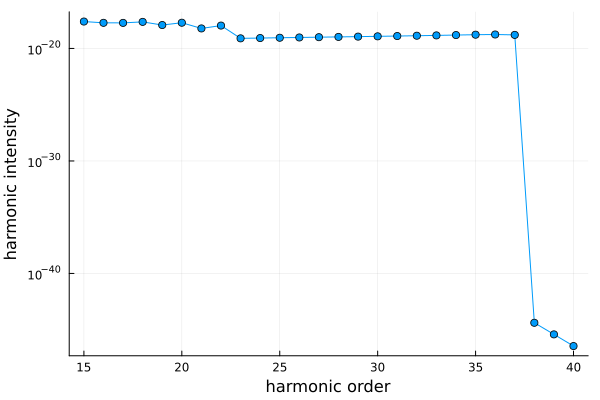

In [51]:
let
    beam = BeamBETC(Intensity1=Intensity1, Intensity2=1*Intensity1, lambda=lambda, r=1, s=2,epsilon=0, phi=π/2)
   
    q_values = sort(unique([tup[1].q for tup in vcat(values(saddlesdict_wo)...)]))
    
    intensities = [harmonic_intensity(beam, dipolesdict_wo[q]..., q) for q in q_values]
    
    plot(q_values, intensities, yaxis= :log, marker=true, 
        legend = false, xlabel = "harmonic order", ylabel = "harmonic intensity")
end

# Debugging

## Calculating intensity for one given order, potentially with finer phi grid

In [609]:
all_saddles_q = let 
    q = 27
    q_values = [q]
    phi_values = range(1,stop = 3, length=100)
    
    arr = Array{Any}(undef, length(phi_values), 2)
    
    
    Threads.@threads for idx in 1:length(phi_values)
        phi = phi_values[idx]
        beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
            Intensity2 = 0.10*Intensity1 , 
            phi = phi )
        
        saddlesDict = get_saddlesTup_Dict_parallel(beam, Ip, q_values, ti_domain, tr_domain)
                
        arr[idx, 1] = phi
        arr[idx, 2] = saddlesDict
    end
    
    arr
end;

In [612]:
all_intensities_q = let
    all_saddles = all_saddles_q
    
    q = 27
    q_values = [q]
    phi_values = range(1,stop = 3, length=100)
    
    arr = Array{Any}(undef, length(phi_values), 2)
    
    for (idx, phi) in enumerate(phi_values)
        beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
            Intensity2 = 0.10*Intensity1 , 
            phi = phi )
        
        saddlesTupDict = all_saddles[idx,2]
        
        dict = Dict{Real,Tuple{Vector{ComplexF64}, Float64}}()
        for q in q_values
            dip = dipole_from_saddles(beam, Ip, saddlesTupDict[q])
            intensity = harmonic_intensity(beam, dip..., q)
            dict[q] = (dip, intensity)
        end        
        
        arr[idx,1] = phi
        arr[idx, 2] = dict
    end
    arr
end;

In [613]:
let 
    q = 27
    phi_values = range(1,stop = 3, length=100)
    
    plt = plot()
    plot!(phi_values, [(el[q][2]) for el in all_intensities_q[:,2]], marker=true, label = "H $q")
#     plot!(ylims=(-18,-14))
    display(plt)
end

In [614]:
let ### the wrong one
    q = 27
    phiidx = 75
    phi_values = range(1,stop = 3, length=100)    
    
    tt(s::Saddle) = (s.tr-s.ti)/TCycle(beam05)
    println("phi: ", phi_values[phiidx])
    println("saddles: ")
    [ println(tup, ", tt:", tt(tup[1])) for tup in sort(all_saddles_q[phiidx,2][q], by = x -> real(x[1].tr))]
    println("dip: ", all_intensities_q[phiidx,2][q][1])
    println("intensity: ", all_intensities_q[phiidx,2][q][2]) ### the wrong one
#      println(unique!( s -> round(s.tr-s.ti, digits=4), [tup[1] for tup in all_saddles_q[phiidx,2][q]]))
end 

phi: 2.494949494949495
saddles: 
(ti: -81.64 + 25.94im, tr: -59.54 + 25.45im, q27.0, true), tt:0.20027478575000002 - 0.004440481675000018im
(ti: -63.35 + 22.35im, tr: -50.51 - 24.37im, q27.0, false), tt:0.11635874430000004 - 0.4233863344im
(ti: -80.44 + 27.84im, tr: -49.21 - 20.25im, q27.0, false), tt:0.283012740225 - 0.43580155867500003im
(ti: -73.38 + 22.51im, tr: -20.39 - 2.75im, q27.0, true), tt:0.48020637542499994 - 0.22891136145000002im
(ti: -75.92 + 23.61im, tr: -20.08 - 4.37im, q27.0, true), tt:0.5060336668000001 - 0.25356056585000003im
(ti: -74.67 + 1.93im, tr: -13.37 + 31.9im, q27.0, false), tt:0.5555133197500001 + 0.271594358775im
(ti: -81.13 + 15.66im, tr: 4.99 + 0.56im, q27.0, true), tt:0.7804373098999999 - 0.13683933325im
(ti: -71.08 + 31.64im, tr: 12.44 - 4.28im, q27.0, false), tt:0.7568755704 - 0.32551449340000005im
dip: ComplexF64[-5.959608391905953e-5 - 4.277978890033719e-5im, 6.9482370442904755e-6 - 5.006951127328641e-6im]
intensity: 1.8861479430525774e-15


In [615]:
let ### the right one
    q = 27
    phiidx = 76
    phi_values = range(1,stop = 3, length=100)    
    
    tt(s::Saddle) = (s.tr-s.ti)/TCycle(beam05)
    println("phi: ", phi_values[phiidx])
    println("saddles: ")
    [ println(tup, ", tt:", tt(tup[1])) for tup in sort(all_saddles_q[phiidx,2][q], by = x -> real(x[1].tr))]
    println("dip: ", all_intensities_q[phiidx,2][q][1])
    println("intensity: ", all_intensities_q[phiidx,2][q][2]) ### the wrong one
#      println(unique!( s -> round(s.tr-s.ti, digits=4), [tup[1] for tup in all_saddles_q[phiidx,2][q]]))
end 

phi: 2.515151515151515
saddles: 
(ti: -81.89 + 26.01im, tr: -59.8 + 25.37im, q27.0, true), tt:0.20018416367500003 - 0.005799812800000005im
(ti: -63.53 + 22.22im, tr: -50.65 - 24.31im, q27.0, false), tt:0.11672123260000003 - 0.421664514975im
(ti: -80.66 + 27.99im, tr: -49.26 - 20.19im, q27.0, false), tt:0.2845533155 - 0.43661715735im
(ti: -76.47 + 24.46im, tr: -20.28 - 4.95im, q27.0, true), tt:0.509205439425 - 0.266519522575im
(ti: -73.19 + 21.69im, tr: -20.03 - 2.39im, q27.0, true), tt:0.4817469507 - 0.2182179566im
(ti: -74.45 + 1.9im, tr: -13.71 + 31.88im, q27.0, false), tt:0.55043848355 + 0.27168498085000004im
(ti: -81.12 + 15.72im, tr: 5.01 + 0.56im, q27.0, true), tt:0.7805279319750001 - 0.1373830657im
(ti: -71.45 + 31.58im, tr: 12.4 - 4.06im, q27.0, false), tt:0.7598660988750001 - 0.3229770753im
dip: ComplexF64[-5.1281375125644014e-5 - 1.1127546576879069e-5im, 2.5039878011813944e-6 - 1.117314790524003e-6im]
intensity: 9.546721695554146e-16


## Plotting oscillation from calculated array

In [573]:
let 
    q = 27
    
    plt = plot()
    plot!(phi_values, [(el[q][2]) for el in all_intensities10[:,2]], marker=true, label = "H $q")
#     plot!(ylims=(1e-18,1e-15))
    display(plt)
end

## Saddle points from dictionary

In [574]:
let 
    all_saddles = all_saddles10
    all_intensities = all_intensities10
    q = 27
    phiidx = 40
    
    tt(s::Saddle) = (s.tr-s.ti)/TCycle(beam05)
    println("phi: ", phi_values[phiidx])
    println("saddles: ")
    [ println(tup, ", tt:", tt(tup[1])) for tup in sort(all_saddles[phiidx,2][q], by = x -> real(x[1].ti))]
    println("dip: ", all_intensities[phiidx,2][q][1])
    println("intensity: ", all_intensities[phiidx,2][q][2])
end 

phi: 2.4751942119192307
saddles: 
(ti: -81.39 + 25.86im, tr: -59.29 + 25.53im, q27.0, false), tt:0.20027478575000002 - 0.0029905284749999848im
(ti: -81.14 + 15.59im, tr: 4.97 + 0.57im, q27.0, true), tt:0.780346687825 - 0.13611435665im
(ti: -80.24 + 27.69im, tr: -49.16 - 20.32im, q27.0, false), tt:0.2816534091 - 0.43507658207500005im
(ti: -75.95 + 22.48im, tr: -19.53 - 3.99im, q27.0, true), tt:0.5112897471500001 - 0.239876632525im
(ti: -74.89 + 1.96im, tr: -13.04 + 31.92im, q27.0, false), tt:0.560497533875 + 0.2715037367im
(ti: -72.99 + 23.61im, tr: -21.09 - 2.91im, q27.0, true), tt:0.47032856924999994 - 0.2403297429im
(ti: -70.73 + 31.71im, tr: 12.48 - 4.5im, q27.0, false), tt:0.7540662860750001 - 0.328142533575im
(ti: -63.18 + 22.48im, tr: -50.39 - 24.44im, q27.0, false), tt:0.115905633925 - 0.42519877590000005im
dip: ComplexF64[-6.93153316591999e-5 - 3.049912952851936e-5im, 4.2007832523316815e-6 - 5.11881962900597e-6im]
intensity: 1.9980032319599998e-15


In [577]:
let 
    all_saddles = all_saddles10
    all_intensities = all_intensities10
    q = 27
    phiidx = 39
    
    tt(s::Saddle) = (s.tr-s.ti)/TCycle(beam05)
    println("phi: ", phi_values[phiidx])
    println("saddles: ")
    [ println(tup, ", tt:", tt(tup[1])) for tup in sort(all_saddles[phiidx,2][q], by = x -> real(x[1].ti))]
    println("dip: ", all_intensities[phiidx,2][q][1])
    println("intensity: ", all_intensities[phiidx,2][q][2])
end 

phi: 2.4117276936648917
saddles: 
(ti: -81.17 + 15.4im, tr: 4.91 + 0.58im, q27.0, true), tt:0.7800748216 - 0.13430191515im
(ti: -80.59 + 25.61im, tr: -58.46 + 25.78im, q27.0, false), tt:0.20054665197500002 + 0.0015405752750000156im
(ti: -79.61 + 27.19im, tr: -49.0 - 20.52im, q27.0, false), tt:0.277394171575 - 0.43235791982500005im
(ti: -76.74 + 20.97im, tr: -18.58 - 3.86im, q27.0, true), tt:0.5270579881999999 - 0.225014612225im
(ti: -75.57 + 2.08im, tr: -11.98 + 31.99im, q27.0, false), tt:0.576265774925 + 0.271050626325im
(ti: -75.25 + 38.15im, tr: -9.51 + 38.31im, q27.0, false), tt:0.59574952105 + 0.0014499532000000336im
(ti: -71.07 + 25.03im, tr: -22.49 - 2.33im, q27.0, true), tt:0.44024204035 - 0.2479419972im
(ti: -69.6 + 31.91im, tr: 12.58 - 5.19im, q27.0, false), tt:0.74473221235 - 0.33620789825im
(ti: -62.57 + 22.89im, tr: -49.97 - 24.66im, q27.0, false), tt:0.11418381450000002 - 0.43090796662499997im
dip: ComplexF64[-6.03016237749497e-5 - 1.6424245117219677e-5im, 3.8649905697627

In [31]:
plotlyjs()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

## plot saddle points in cp

In [579]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.10*Intensity1,
    phi=  2.42);

    q_values = collect(range(25, stop = 35, step = 1 ));
    
    saddlesTup_Dict = get_saddlesTup_Dict(beam, Ip, q_values, ti_domain, tr_domain)
    
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    
    plot_sp_times_cp(beam, 
        vcat(values(saddlesTup_Dict)...), 
        filter(x -> 0 < real(x.qhc) < 45, thcs),
        ti_domain, tr_domain)  
end

In [629]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.10*Intensity1,
    phi = 2.5);

    q_values = collect(range(25, stop = 35, step = 1 ));
    
    saddlesTup_Dict = get_saddlesTup_Dict_parallel(beam, Ip, q_values, ti_domain, tr_domain)
    
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain)
    
    plot_sp_times_cp(beam, 
        vcat(values(saddlesTup_Dict)...), 
        filter(x -> 0 < real(x.qhc) < 45, thcs),
        ti_domain, tr_domain)  
end

## find saddles sobol & relevant?

In [516]:
include("src/SolveSPE2.jl");

In [103]:
### get_saddlesTup_Dict()
@time begin let 
    b = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)
    beam = b

    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
    tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam); 
    ti_cd = ti_domain; tr_cd = tr_domain
        
    q = 36

    for sd in saddlesdict[q]
        print(sd[1]/TCycle(beam))
        println(" ==> ",sd[2])
    end
        println()
    saddles = find_saddles_sobol(q, b=b, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N=200, tt_minimal =0.005)
#     println("tt_minimal: ", 0.005*TCycle(b))
#         vec = Vector{Tuple{Saddle,Bool}}()
    for s in saddles 
        ti_relevant = is_saddle_relevant_ti(b, Ip, s, ti_cd, tr_cd)
        tr_relevant = is_saddle_relevant_tr(b, Ip, s, ti_cd, tr_cd)
        println(s/TCycle(b))
#             println(s.tr-s.ti)
        println(" => ti relevant: ", ti_relevant, ", tr relevant: ", tr_relevant)
#             relevant = ti_relevant && tr_relevant
#             push!(vec, (s,relevant))
    end
  
end
end

ti: 0.22846 + 0.18795im, tr: 0.57998 - 0.10838im, q36.0 ==> false
ti: 0.22882 + 0.15089im, tr: 0.55144 + 0.10286im, q36.0 ==> true
ti: 0.23317 + 0.1739im, tr: 0.8678 - 0.020299im, q36.0 ==> true
ti: 0.23997 + 0.17771im, tr: 0.92489 + 0.011781im, q36.0 ==> true
ti: 0.25202 + 0.1817im, tr: 1.1618 - 0.18768im, q36.0 ==> false
ti: 0.25365 + 0.17354im, tr: 1.1624 + 0.18686im, q36.0 ==> true
ti: 0.26271 + 0.18623im, tr: 0.34291 - 0.19855im, q36.0 ==> false

ti: 0.22846 + 0.18795im, tr: 0.57998 - 0.10838im, q36.0
 => ti relevant: true, tr relevant: false
ti: 0.22882 + 0.15089im, tr: 0.55144 + 0.10286im, q36.0
 => ti relevant: true, tr relevant: true
ti: 0.23317 + 0.1739im, tr: 0.8678 - 0.020299im, q36.0
 => ti relevant: true, tr relevant: true
ti: 0.23997 + 0.17771im, tr: 0.92489 + 0.011781im, q36.0
 => ti relevant: true, tr relevant: true
ti: 0.25202 + 0.1817im, tr: 1.1618 - 0.18768im, q36.0
 => ti relevant: true, tr relevant: false
ti: 0.25365 + 0.17354im, tr: 1.1624 + 0.18686im, q36.0
 => 

In [608]:
### get_saddlesTup_Dict()
@time begin let 
    b = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.10*Intensity1,
    phi= 2.52);


    ti_cd = ti_domain; tr_cd = tr_domain  
 
    q = 27

    saddles = find_saddles_sobol(q, b=b, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N=120, tt_minimal =0.005)
    println("tt_minimal: ", 0.005*TCycle(b))
#         vec = Vector{Tuple{Saddle,Bool}}()
    for s in saddles 
        ti_relevant = is_saddle_relevant_ti(b, Ip, s, ti_cd, tr_cd)
#             println(imag(s.tr))
        tr_relevant = is_saddle_relevant_tr(b, Ip, s, ti_cd, tr_cd)
        println(s/TCycle(b))
#             println(s.tr-s.ti)
        println(" => ti relevant: ", ti_relevant, ", tr relevant: ", tr_relevant)
#             relevant = ti_relevant && tr_relevant
#             push!(vec, (s,relevant))
    end

end
end

tt_minimal: 0.5517419458779773
ti: -0.74265 + 0.23589im, tr: -0.54246 + 0.22973im, q27.0
 => ti relevant: true, tr relevant: true
ti: -0.73504 + 0.14264im, tr: 0.045402 + 0.0049842im, q27.0
 => ti relevant: true, tr relevant: true
ti: -0.73141 + 0.25401im, tr: -0.44649 - 0.18288im, q27.0
 => ti relevant: true, tr relevant: false
ti: -0.69417 + 0.22302im, tr: -0.18396 - 0.045945im, q27.0
 => ti relevant: true, tr relevant: true
ti: -0.67423 + 0.017128im, tr: -0.12497 + 0.2889im, q27.0
 => ti relevant: true, tr relevant: false
ti: -0.66281 + 0.19529im, tr: -0.18106 - 0.021024im, q27.0
 => ti relevant: true, tr relevant: true
ti: -0.64831 + 0.286im, tr: 0.11237 - 0.036339im, q27.0
 => ti relevant: false, tr relevant: true
ti: -0.57608 + 0.20109im, tr: -0.45927 - 0.22021im, q27.0
 => ti relevant: true, tr relevant: false
  1.679837 seconds (24.82 M allocations: 2.205 GiB, 19.01% gc time)


### inside find saddle sobol

In [474]:
let 
    b = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.07*Intensity1,
    phi= 1.1423973285781066);

#     ti_cd = ti_domain; tr_cd = tr_domain  
    ti_cd2 = ComplexDomain(-0.55,-0.5,0.,0.09)*TCycle(b);
    tr_cd2 = ComplexDomain(-0.51,-0.48,0.,0.09)*TCycle(b);   

    ti_cd = ComplexDomain(-0.76,-0.4765,0.,0.45)*TCycle(b);
    tr_cd = ComplexDomain(-0.65,0.25,-0.35,0.4)*TCycle(b);  
    
    q = 19.

    N = 120
    tt_minimal = 0.005
        
    roundDigits = 4

	SP_array = Vector{Saddle}()
    
    ti_seq = SobolSeq(reim(ti_cd.min),reim(ti_cd.max))
    tr_seq = SobolSeq(reim(tr_cd.min),reim(tr_cd.max))    
    
#     ti_seq = SobolSeq(reim(-60. + 5im),reim(-55. + 7im))
#     tr_seq = SobolSeq(reim(-59. + 5im),reim(-55. + 7im))

	for i in 1:10
        ti0 = next!(ti_seq)
        tr0 = next!(tr_seq)
#         ti0 = reim(-57.514 + 6.0959im)
#         tr0 = reim(-54.705 + 6.1647im)
        
        t0 = [ti0[1]; ti0[2]; tr0[1]; tr0[2]]
#         t0 = [-58.69111844437462, 33.7510893455044, 8.189919509126227, 17.629879364382248]
#         speq10 = speq1(b, Ip, t0...)
#         speq20 = speq2(b, Ip, q, t0...)
        
#         println(speq10)
#         println(speq20)
        
        
        
        function speqs!(F, x)
            F[1] = real(speq1(b, Ip, x[1],x[2],x[3],x[4]))
            F[2] = real(speq2(b, Ip, q, x[1],x[2],x[3],x[4]))
            F[3] = imag(speq1(b, Ip, x[1],x[2],x[3],x[4]))
            F[4] = imag(speq2(b, Ip, q, x[1],x[2],x[3],x[4]))
        end
        
        println(nlsolve(speqs!, t0))

        
        
               
        
#         tiSP, trSP = solve_SPEqs(q, t0, b, Ip, roundDigits) # last arg: rounddigits

        result = nlsolve(speqs!, t0)#, method = :trust_region, factor =fac )#, ftol = 1e-13)#, method = :anderson)
        println(result)
        if converged(result)
            tiSP = result.zero[1] + im*result.zero[2]
            trSP = result.zero[3] + im*result.zero[4]
            tiSP = round(tiSP, digits = roundDigits)
            trSP = round(trSP, digits = roundDigits)
        else 
            tiSP, trSP = nothing,nothing
        end
#         return tiSP, trSP        
        
        
        
        
        if in(tiSP, ti_cd2)  && in(trSP, tr_cd2) 
            
        println("--> tiSP: $(round(tiSP,digits=5)), trSP: $(round(trSP,digits=5)).")
        println("t0: $(t0)")
        println(speq2(b, Ip, q,real(tiSP), imag(tiSP), real(trSP), imag(trSP)))
        println("  check sp:", check_sp(b, tiSP, trSP, tt_minimal = tt_minimal) )
        println("  in ticd: ",in(tiSP, ti_cd)  )
        println("  in trcd: ",in(trSP, tr_cd)  )
        end
        ### check conditions and zwischen-store in array

	end

#     unique!( s -> round(s.tr-s.ti, digits=roundDigits), SP_array)
#     sort!(SP_array, by = x -> real(x.ti))
# 	return SP_array
end

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [-68.22289160781189, 24.82838756450898, -22.069677835119094, 2.758709729389892]
 * Zero: [-74.10118915932804, 17.20180543746188, -26.618253194034967, -2.459559570074806]
 * Inf-norm of residuals: 0.000000
 * Iterations: 6
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 7
 * Jacobian Calls (df/dx): 7
Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [-68.22289160781189, 24.82838756450898, -22.069677835119094, 2.758709729389892]
 * Zero: [-74.10118915932804, 17.20180543746188, -26.618253194034967, -2.459559570074806]
 * Inf-norm of residuals: 0.000000
 * Iterations: 6
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 7
 * Jacobian Calls (df/dx): 7
Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region

## action landscapes

the chosen one: ti: 0.23317 + 0.1739im, tr: 0.8678 - 0.020299im, q36.0
ti check relevant: asc true, crossing true => ti true
S saddle: -133.68201734849714 - 10.794823693695506im
ip: Point{Float64}(0.8514305637194818, -1.0842021724855044e-19)
 S ip: -133.68177535321135 - 11.067049728269183im
 diff: -0.2722
tr check relevant: asc false, crossing true
ip: Point{Float64}(0.8978354481816814, 0.0)
 S ip: -133.68207033118347 - 10.48228192626129im
 diff: 0.3125
tr check relevant: asc true, crossing true
==> tr relevant: true


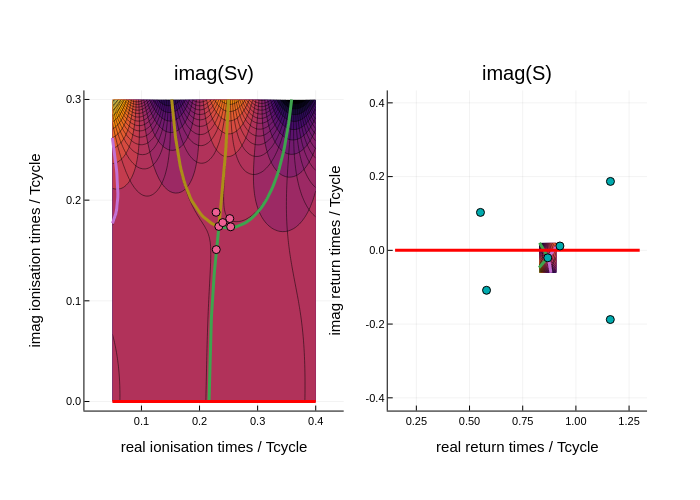

In [111]:
let 
#     beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
#         Intensity2=0.02*Intensity1, phi=2.0)
    b = BeamBETC(Intensity1=Intensity1, 
        Intensity2=1*Intensity1,
        lambda=lambda, r=1,s=2,epsilon=0,
        phi=π/2)
    beam = b

    ti_domain = ComplexDomain(0.15,0.3,0.0,0.3)*TCycle(beam);
    tr_domain = ComplexDomain(0.15,1.3,-0.35,0.35)*TCycle(beam); 
    ti_cd = ti_domain; tr_cd = tr_domain

    TC = TCycle(beam)
    
#     ti_cd = ti_domain #ComplexDomain(-0.8,-0.5,0.075,0.3)*TCycle(beam);
#     tr_cd = tr_domain #ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
       
    q = 36
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N=150) 
#     [println(s) for s in saddles]
    idx = 3
    println("the chosen one: ", saddles[idx]/TC)

    ### ionisation time
    plt_ti = let 
        tir_values = range(real(ti_cd.min)-0.1*TC, stop=real(ti_cd.max)+0.1*TC, length=75)
        tii_values = range(min(imag(ti_cd.min), 0.), stop = imag(ti_cd.max), length=75)   
        tr = saddles[idx].tr

        Sv_values = [S_v(beam, Ip, ti, tr) for ti in (tir_values' .+ im*tii_values)]
        SvDrv_values = [dSv_dti(beam, Ip, ti, tr) for ti in (tir_values' .+ im*tii_values ) ]

        ImSv_values, _ = normalize(imag.(Sv_values))
        ReSv_values, _ = normalize(real.(Sv_values))

        plt1 = Plots.contour(tir_values./TC, tii_values./TC, ImSv_values
            , fill = true, aspectratio = 1, legend = false
            , levels = 30, linestyle = :solid
            , xlabel = "real ionisation times / Tcycle" , ylabel = "imag ionisation times / Tcycle"
            , title = "imag(Sv)");


        Plots.contour!(plt1, tir_values./TC, tii_values./TC, ReSv_values
            , fill = false, linestyle = :solid, c= :black, levels = 51)   

        Sv_saddle = (S_v(beam, Ip, saddles[idx]))

        mycurve = Curve2([(minimum(tir_values)./TC, 0.), (maximum(tir_values)./TC, 0.)])    

        con_S_saddle_real = Contour.contour(tir_values./TC, tii_values./TC, real.(Sv_values'), real.(Sv_saddle))

#         println(imag(Sv_saddle))
        for curve in lines(con_S_saddle_real)
            ip = intersection(curve,mycurve)
            for ipx in ip
                ti = (ipx.x + ipx.y*im)*TC
                Sv_ip = S_v(beam, Ip, ti, tr)
                ascending = imag(Sv_ip - Sv_saddle) > 0 
                crossespoint = crosses_point(curve,Point(reim(saddles[idx].ti)./TC...),max(tii_values[2]-tii_values[1], 1.5))
                println("ti check relevant: asc $(ascending), crossing $crossespoint => ti ", ascending && crossespoint )
            end
            plot!(plt1, coordinates(curve),  lw = 3)
        end 
        plot!(plt1,coordinates(mycurve), c = :red, lw = 3)
        scatter!(plt1,[reim(s.ti)./TC for s in saddles])
    end;
    ### recombination time
    
    plt_tr = let
        relevant = false

        str = saddles[idx].tr
        rg = max(abs(imag(saddles[idx].tr)),0.01*TC ) * 2.#1.25 #
#          println(abs(imag(saddles[idx].tr)))
#         println(0.01*TC)
        trr_values = range(real(str) - rg, stop = real(str) + rg, length=51)
        tri_values = range(imag(str) - rg, stop = imag(str) + rg, length=51)
#         tri_values = range(min(imag(tr_cd.min),0.), stop= min( imag(tr_cd.max), imag(saddles[idx].tr) ), length=200)        

#         println("step tri: ", tri_values[2]-tri_values[1])
        ti = saddles[idx].ti

        S_values = [S(beam, Ip, ti, tr, q) for tr in (trr_values' .+ im*tri_values)]

        ImS_values, maxi = normalize(imag.(S_values))
        ReS_values, maxiR = normalize(real.(S_values))

        plt2 = Plots.contour(trr_values./TC, tri_values./TC, ImS_values
            , fill = true, aspectratio = 1, legend = false, levels = 30, linestyle = :solid
            , xlabel = "real return times / Tcycle" , ylabel = "imag return times / Tcycle", title = "imag(S)")

        Plots.contour!(trr_values./TC, tri_values./TC, ReS_values
            , fill = false, linestyle = :solid, c= :black, levels = 51)   

        S_saddle = (S(beam, Ip, saddles[idx]))
        con_S_saddle = Contour.contour(trr_values./TC, tri_values./TC, ImS_values', imag.(S_saddle)/maxi)

        mycurve = Curve2([(real(tr_cd.min)./TC, -0.0),(real(tr_cd.max)./TC, -0.0)])

        println("S saddle: ", S_saddle)
        con_S_saddle_real = Contour.contour(trr_values./TC, tri_values./TC, real.(S_values'), real.(S_saddle))
        for curve in lines(con_S_saddle_real)
            ip = intersection(curve,mycurve)
            for ipx in ip
                tr = round((ipx.x + ipx.y*im)*TC, digits=3)
                S_ip = S(beam, Ip, ti, tr, saddles[idx].q)
                
                println("ip: ", ipx)
                println(" S ip: ", S_ip)
                println(" diff: ", round(imag(S_ip - S_saddle), digits=4))
                
                ascending = round(imag(S_ip - S_saddle),digits=4) >= 0
                crossespoint = crosses_point(curve, Point(reim(saddles[idx].tr)./TC...), max(tri_values[2]-tri_values[1], 1.))
                println("tr check relevant: asc $(ascending), crossing $crossespoint")
                if ascending && crossespoint
                    relevant = true 
                end 
            end
           
            plot!(coordinates(curve), lw = 3)
        end
        println("==> tr relevant: ", relevant)
        plot!(coordinates(mycurve), c = :red, lw = 3)
#            plot!(xlims=(-0.25,-0.15), ylims = (-0.05,0.05))
        scatter!(plt2,[reim(s.tr)./TC for s in saddles])
        plt2
    end
    
    plot(plt_ti, plt_tr, layout=(1,2), size =(800,300))
end

In [ ]:
67.8484151763391 - 8.102406713965188im

In [628]:
let 
    idx = 6
    beam = BeamBEOTC(Intensity1=Intensity1, lambda=lambda, r=1, s=2, epsilon=epsilon,
    Intensity2=0.10*Intensity1,
    phi= 2.52);
    
        TC = TCycle(beam)    
        ti_cd = ti_domain #ComplexDomain(-0.8,-0.5,0.075,0.3)*TCycle(beam);
        tr_cd = tr_domain #ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
       
    q = 27
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_cd, tr_cd = tr_cd, N=150) 
#     [println(s) for s in saddles]
    println("the chosen one: ", saddles[idx]/TC)

    ### ionisation time
    plt_ti = let 
        tir_values = range(real(ti_cd.min)-0.1*TC, stop=real(ti_cd.max)+0.1*TC, length=75)
        tii_values = range(min(imag(ti_cd.min), 0.), stop = imag(ti_cd.max), length=75)   
        tr = saddles[idx].tr

        Sv_values = [S_v(beam, Ip, ti, tr) for ti in (tir_values' .+ im*tii_values)]
        SvDrv_values = [dSv_dti(beam, Ip, ti, tr) for ti in (tir_values' .+ im*tii_values ) ]

        ImSv_values, _ = normalize(imag.(Sv_values))
        ReSv_values, _ = normalize(real.(Sv_values))

        plt1 = Plots.contour(tir_values./TC, tii_values./TC, ImSv_values
            , fill = true, aspectratio = 1, legend = false
            , levels = 30, linestyle = :solid
            , xlabel = "real ionisation times / Tcycle" , ylabel = "imag ionisation times / Tcycle"
            , title = "imag(Sv)");


        Plots.contour!(plt1, tir_values./TC, tii_values./TC, ReSv_values
            , fill = false, linestyle = :solid, c= :black, levels = 51)   

        Sv_saddle = (S_v(beam, Ip, saddles[idx]))

        mycurve = Curve2([(minimum(tir_values)./TC, 0.), (maximum(tir_values)./TC, 0.)])    

        con_S_saddle_real = Contour.contour(tir_values./TC, tii_values./TC, real.(Sv_values'), real.(Sv_saddle))

#         println(imag(Sv_saddle))
        for curve in lines(con_S_saddle_real)
            ip = intersection(curve,mycurve)
            for ipx in ip
                ti = (ipx.x + ipx.y*im)*TC
                Sv_ip = S_v(beam, Ip, ti, tr)
                ascending = imag(Sv_ip - Sv_saddle) > 0 
                crossespoint = crosses_point(curve,Point(reim(saddles[idx].ti)./TC...),max(tii_values[2]-tii_values[1], 1.5))
                println("ti check relevant: asc $(ascending), crossing $crossespoint => ti ", ascending && crossespoint )
            end
            plot!(plt1, coordinates(curve),  lw = 3)
        end 
        plot!(plt1,coordinates(mycurve), c = :red, lw = 3)
        scatter!(plt1,[reim(s.ti)./TC for s in saddles])
    end;
    ### recombination time
    plt_tr = let
        relevant = false

        str = saddles[idx].tr
        rg = max(abs(imag(saddles[idx].tr)),0.01*TC ) * 1.1 #
#         println(rg)
        trr_values = range(real(str) - rg, stop = real(str) + rg, length=51)
        tri_values = range(imag(str) - rg, stop = imag(str) + rg, length=51)
#         tri_values = range(min(imag(tr_cd.min),0.), stop= min( imag(tr_cd.max), imag(saddles[idx].tr) ), length=200)        

#         println("step tri: ", tri_values[2]-tri_values[1])
        ti = saddles[idx].ti

        S_values = [S(beam, Ip, ti, tr, q) for tr in (trr_values' .+ im*tri_values)]

        ImS_values, maxi = normalize(imag.(S_values))
        ReS_values, maxiR = normalize(real.(S_values))

        plt2 = Plots.contour(trr_values./TC, tri_values./TC, ImS_values
            , fill = true, aspectratio = 1, legend = false, levels = 30, linestyle = :solid
            , xlabel = "real return times / Tcycle" , ylabel = "imag return times / Tcycle", title = "imag(S)")

        Plots.contour!(trr_values./TC, tri_values./TC, ReS_values
            , fill = false, linestyle = :solid, c= :black, levels = 51)   

        S_saddle = (S(beam, Ip, saddles[idx]))
        con_S_saddle = Contour.contour(trr_values./TC, tri_values./TC, ImS_values', imag.(S_saddle)/maxi)

        mycurve = Curve2([(real(tr_cd.min)./TC, -0.0),(real(tr_cd.max)./TC, -0.0)])

        println("S saddle: ", S_saddle)
        con_S_saddle_real = Contour.contour(trr_values./TC, tri_values./TC, real.(S_values'), real.(S_saddle))
        for curve in lines(con_S_saddle_real)
            ip = intersection(curve,mycurve)
            for ipx in ip
                tr = round((ipx.x + ipx.y*im)*TC, digits=3)
                S_ip = S(beam, Ip, ti, tr, saddles[idx].q)
                
                println("ip: ", ipx)
                println(" S ip: ", S_ip)
                println(" diff: ", round(imag(S_ip - S_saddle), digits=4))
                
                ascending = round(imag(S_ip - S_saddle),digits=4) >= 0
                crossespoint = crosses_point(curve, Point(reim(saddles[idx].tr)./TC...), max(tri_values[2]-tri_values[1], 1.))
                println("tr check relevant: asc $(ascending), crossing $crossespoint")
                if ascending && crossespoint
                    relevant = true 
                end 
            end
           
            plot!(coordinates(curve), lw = 3)
        end
        println("==> tr relevant: ", relevant)
        plot!(coordinates(mycurve), c = :red, lw = 3)
#            plot!(xlims=(-0.25,-0.15), ylims = (-0.05,0.05))
        scatter!(plt2,[reim(s.tr)./TC for s in saddles])
        plt2
    end
    
    plot(plt_ti, plt_tr, layout=(1,2), size =(800,300))
end

the chosen one: ti: -0.66281 + 0.19529im, tr: -0.18106 - 0.021024im, q27.0
ti check relevant: asc true, crossing true => ti true
S saddle: 67.58986464391819 - 7.997406318835804im
ip: Point{Float64}(-0.16422916062541584, 0.0)
 S ip: 67.58991718835439 - 7.7707187838917955im
 diff: 0.2267
tr check relevant: asc true, crossing true
==> tr relevant: true
